# Adding LC Data to a Dataframe of EBs

In [1]:
import lightkurve as lk
from lightkurve import search_lightcurve
import matplotlib.pyplot as plt
import requests
import pandas as pd
from time import perf_counter
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

%matplotlib inline


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

In [2]:
def queryMAST(KOI):
    """
    Use the MAST API to get info about the canonical name and KIC of a Kepler Object of Interest (KOI).
    Returns: JSON object with information about object with it's KIC as one of it's fields.
    """
    # Resolve KOI -> Kepler ID / canonical name using Exo.MAST
    info = requests.get(
        "https://exo.mast.stsci.edu/api/v0.1/exoplanets/identifiers/",
        params={"name": KOI},
        timeout=30,
    ).json()
    
    return info


In [3]:
def fetchStitchedLC(KIC):
    """
    Given a KIC, fetch it's light curve data using LC.
    Returns: Stitched LC object.
    """
    search = lk.search_lightcurve(
        f"KIC {KIC}",
        mission="Kepler",
        author="Kepler",
        cadence="long"
    )

    return search.download_all().stitch().remove_nans()


In [4]:
def getLCArraysOriginal(kic):
    lc = fetchStitchedLC(kic)
    
    return pd.Series({
        "time": lc.time.value,
        "flux": lc.flux.value,
        "flux_err": lc.flux_err.value if lc.flux_err is not None else None,
        "n_points": len(lc),
    })


In [5]:
def getLCArrays(kic):
    """
    Fetches LC arrays and returns a pandas Series. 
    Includes error handling to prevent pipeline crashes.
    """
    try:
        lc = fetchStitchedLC(kic)
        
        if lc is None:
            return pd.Series({"time": None, "flux": None, "flux_err": None, "n_points": 0}, name=kic)
            
        return pd.Series({
            "time": lc.time.value,
            "flux": lc.flux.value,
            "flux_err": lc.flux_err.value if lc.flux_err is not None else None,
            "n_points": len(lc),
        }, name=kic)
        
    except Exception as e:
        # Catch network timeouts or corrupted downloads and return empty/NaN data
        # so the rest of the dataset can continue processing.
        return pd.Series({"time": None, "flux": None, "flux_err": None, "n_points": 0}, name=kic)


In [6]:
def fetchLightCurvesParallel(df, max_workers=10):
    """
    Parallelizes the downloading and feature extraction of lightcurves.
    """
    kic_list = df.index.tolist()
    results = []

    # Using ThreadPoolExecutor because network requests are I/O bound
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Map KICs to their future objects
        future_to_kic = {executor.submit(getLCArrays, kic): kic for kic in kic_list}

        # as_completed yields futures as they finish, allowing the progress bar to update
        for future in tqdm(as_completed(future_to_kic), total=len(kic_list), desc="Downloading Kepler LCs"):
            results.append(future.result())

    # Compile all processed series into a new DataFrame
    features_df = pd.DataFrame(results)
    
    # Join the new features back to the original DataFrame based on the KIC index
    return df.join(features_df)


In [7]:
def plotLightCurve(df, kic, with_error=True):
    """
    Plot the light curve for a given KIC from a DataFrame.
    """
    row = df[df["KIC"] == kic]
    
    if row.empty:
        raise ValueError(f"KIC {kic} not found in DataFrame.")
    
    row = row.iloc[0]
    
    t = row["time"]
    f = row["flux"]
    e = row.get("flux_err", None)

    # Plot
    plt.figure(figsize=(20, 5))
    
    if with_error and e is not None:
        plt.errorbar(t, f, yerr=e, fmt='-', linewidth=1)
    else:
        plt.plot(t, f, linewidth=1)
    
    plt.xlabel("Time")
    plt.ylabel(r"Normalized Flux (e$^{-}$ s$^{-1}$)")
    plt.title(f"KIC {kic} Light Curve")
    plt.show()
    

In [8]:
def sampleRandomKEB(df):
    idx = np.random.randint(0, len(df))
    kic = int(df.loc[idx]['KIC'])

    return kic


---

In [9]:
df = pd.read_csv(r"../assets/data/kepler-eclipsing-binary-catalog.csv")


In [10]:
df = df.drop(columns=["Unnamed: 11"])


In [11]:
df.head()


,KIC,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC
0,3863594,0.053268,0.0,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False
1,10417986,0.073731,0.0,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True
2,8912468,0.094838,0.0,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False
3,8758716,0.107205,0.0,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False
4,10855535,0.112782,0.0,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False


In [12]:
# listOfKICs = df['KIC'].astype(int).tolist()


---

Now, using a copy of the dataframe to test converting the lightcurve into arrays from being an LC object.

In [13]:
copyDf = df.head(20).copy()


In [14]:
copyDf[["time", "flux", "flux_err", "n_points"]] = copyDf["KIC"].apply(getLCArrays)


In [15]:
copyDf


,KIC,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC,time,flux,flux_err,n_points
0,3863594,0.053268,0.000000e+00,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False,"[120.53895485026442, 120.55938947320828, 120.5...","[1.0027486, 0.9967121, 0.9994276, 0.9998087, 0...","[9.646405e-05, 9.793051e-05, 9.82528e-05, 9.78...",52286
1,10417986,0.073731,0.000000e+00,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True,"[120.53855550513981, 120.55898988617264, 120.5...","[0.99979115, 0.9999734, 0.99954855, 0.9999474,...","[1.3734762e-05, 1.36594945e-05, 1.3738576e-05,...",52200
2,8912468,0.094838,0.000000e+00,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False,"[120.53837293142715, 120.55880740127031, 120.5...","[0.9991674, 0.99967396, 0.9959102, 1.0009913, ...","[5.4617427e-05, 5.4451953e-05, 5.4505457e-05, ...",65266
3,8758716,0.107205,0.000000e+00,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False,"[120.53883156277152, 120.55926600434032, 120.5...","[1.0111475, 0.9915452, 1.0019422, 1.0050972, 0...","[0.00011227019, 0.000111015965, 0.000111714115...",65262
4,10855535,0.112782,0.000000e+00,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False,"[131.51221361904754, 131.5326480107833, 131.55...","[0.9962518, 1.004716, 1.0054883, 0.9961573, 1....","[0.0001593724, 0.0001598708, 0.0001599348, 0.0...",64793
5,9472174,0.125765,1.000000e-07,54953.643178,0.018318,0.78,79.0187,11.6745,12.264,10645.0,True,"[120.53873908418609, 120.55917349758238, 120.5...","[0.97662395, 0.9745588, 1.014877, 0.989838, 0....","[6.300036e-05, 6.467215e-05, 6.5689615e-05, 6....",65262
6,9612468,0.133471,1.000000e-07,54953.603803,0.007796,0.99,81.0112,8.5285,11.531,7202.0,False,"[120.53835217891174, 120.55878661484894, 120.5...","[0.9995563, 0.9997012, 1.0000107, 0.9993931, 0...","[4.8257938e-05, 4.8070073e-05, 4.819779e-05, 4...",65266
7,6613627,0.150800,1.000000e-07,55115.344848,0.008552,0.98,75.1606,10.2517,12.548,7090.0,False,"[120.53893169508228, 120.55936622250738, 120.5...","[0.99867725, 0.9994301, 0.9975974, 0.99530953,...","[6.94462e-05, 6.992977e-05, 7.0209004e-05, 6.9...",65262
8,5302006,0.151171,1.000000e-07,54980.509040,0.007895,0.97,75.3495,6.6449,15.050,6536.0,False,"[131.512027738936, 131.53246243730973, 131.552...","[0.9980388, 1.0001712, 0.99408454, 0.99844176,...","[0.00038361122, 0.0003847312, 0.00038426358, 0...",64797
9,9898401,0.152774,1.000000e-07,54964.733972,0.008810,0.99,79.6654,11.8375,12.073,7376.0,False,"[131.51197270999546, 131.53240720440954, 131.5...","[0.99978876, 1.0012784, 1.0014253, 0.99926335,...","[5.689676e-05, 5.6929643e-05, 5.6972345e-05, 5...",64793


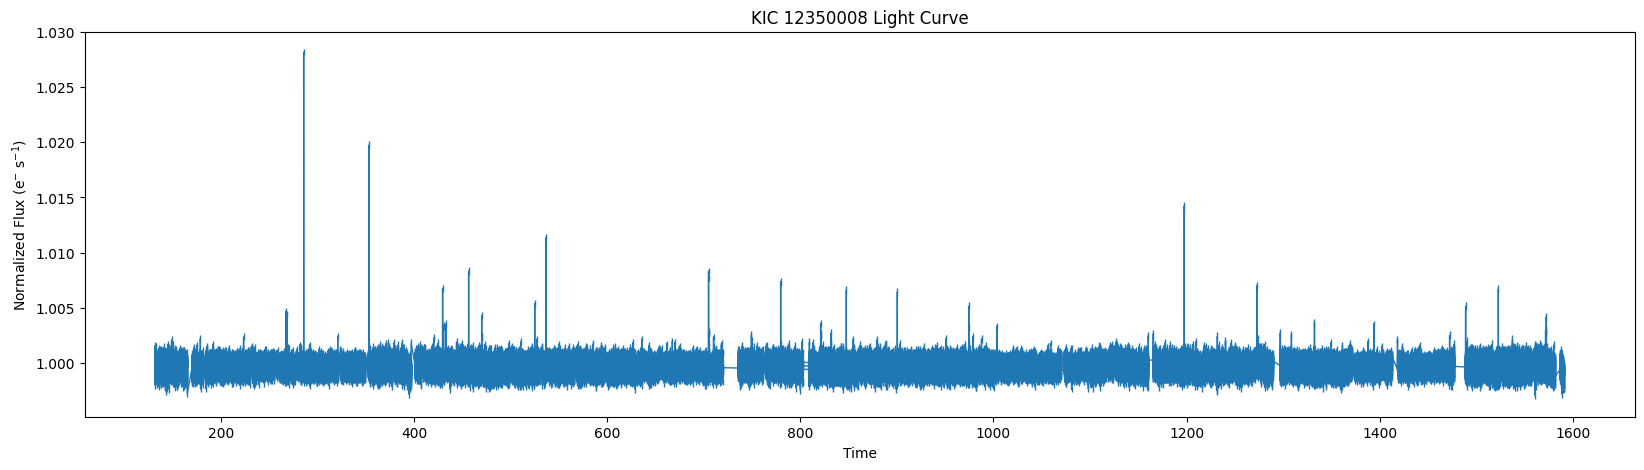

In [ ]:
plotLightCurve(copyDf, 12350008)


In [17]:
# Doesn't really make sense 'cos the LC seems to be normalized already
# df["flux_mean"] = df["flux"].apply(np.mean)
# df["flux_std"] = df["flux"].apply(np.std)


In [18]:
copyDf


,KIC,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC,time,flux,flux_err,n_points
0,3863594,0.053268,0.000000e+00,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False,"[120.53895485026442, 120.55938947320828, 120.5...","[1.0027486, 0.9967121, 0.9994276, 0.9998087, 0...","[9.646405e-05, 9.793051e-05, 9.82528e-05, 9.78...",52286
1,10417986,0.073731,0.000000e+00,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True,"[120.53855550513981, 120.55898988617264, 120.5...","[0.99979115, 0.9999734, 0.99954855, 0.9999474,...","[1.3734762e-05, 1.36594945e-05, 1.3738576e-05,...",52200
2,8912468,0.094838,0.000000e+00,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False,"[120.53837293142715, 120.55880740127031, 120.5...","[0.9991674, 0.99967396, 0.9959102, 1.0009913, ...","[5.4617427e-05, 5.4451953e-05, 5.4505457e-05, ...",65266
3,8758716,0.107205,0.000000e+00,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False,"[120.53883156277152, 120.55926600434032, 120.5...","[1.0111475, 0.9915452, 1.0019422, 1.0050972, 0...","[0.00011227019, 0.000111015965, 0.000111714115...",65262
4,10855535,0.112782,0.000000e+00,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False,"[131.51221361904754, 131.5326480107833, 131.55...","[0.9962518, 1.004716, 1.0054883, 0.9961573, 1....","[0.0001593724, 0.0001598708, 0.0001599348, 0.0...",64793
5,9472174,0.125765,1.000000e-07,54953.643178,0.018318,0.78,79.0187,11.6745,12.264,10645.0,True,"[120.53873908418609, 120.55917349758238, 120.5...","[0.97662395, 0.9745588, 1.014877, 0.989838, 0....","[6.300036e-05, 6.467215e-05, 6.5689615e-05, 6....",65262
6,9612468,0.133471,1.000000e-07,54953.603803,0.007796,0.99,81.0112,8.5285,11.531,7202.0,False,"[120.53835217891174, 120.55878661484894, 120.5...","[0.9995563, 0.9997012, 1.0000107, 0.9993931, 0...","[4.8257938e-05, 4.8070073e-05, 4.819779e-05, 4...",65266
7,6613627,0.150800,1.000000e-07,55115.344848,0.008552,0.98,75.1606,10.2517,12.548,7090.0,False,"[120.53893169508228, 120.55936622250738, 120.5...","[0.99867725, 0.9994301, 0.9975974, 0.99530953,...","[6.94462e-05, 6.992977e-05, 7.0209004e-05, 6.9...",65262
8,5302006,0.151171,1.000000e-07,54980.509040,0.007895,0.97,75.3495,6.6449,15.050,6536.0,False,"[131.512027738936, 131.53246243730973, 131.552...","[0.9980388, 1.0001712, 0.99408454, 0.99844176,...","[0.00038361122, 0.0003847312, 0.00038426358, 0...",64797
9,9898401,0.152774,1.000000e-07,54964.733972,0.008810,0.99,79.6654,11.8375,12.073,7376.0,False,"[131.51197270999546, 131.53240720440954, 131.5...","[0.99978876, 1.0012784, 1.0014253, 0.99926335,...","[5.689676e-05, 5.6929643e-05, 5.6972345e-05, 5...",64793


---

In [19]:
# df[["time", "flux", "flux_err", "n_points"]] = df["KIC"].apply(getLCArrays)


> **This took 212 mins to get halfway through the dataset.**

---

In [20]:
# kebLCs = fetchLightCurvesParallel(copyDf, max_workers=6)


In [21]:
# kebLCs.head()
# 


In [22]:
# df.to_json("../assets/data/keb-lcs.json")
